In [1]:
import os
import json
import mlflow
import seaborn as sns
import matplotlib.pyplot as plt
from workspace.sources.local_datasets.dataset import Dataset
from sklearn.metrics import confusion_matrix
from workspace.sources.experiments.metrics import Precision

mlflow.set_tracking_uri('../../mlruns')

In [2]:
experiment_name = 'prefinal-bert-base-uncased'
run_id = 'd55ebe7823f54c7291992fb26b51da64'

In [3]:
client = mlflow.tracking.MlflowClient()
run = client.get_run(run_id)

### Confusion Matrix


In [4]:
by_metric = Precision

In [5]:
by_metric_dir_path = f'evaluation/by_{by_metric.name}'
artifacts_path = client.download_artifacts(run_id=run_id, path=by_metric_dir_path)
print(artifacts_path)

C:\Users\nikita.bardatskii\git\bi-bap-2025-bardanik\workspace\mlruns\847989095527904331\d55ebe7823f54c7291992fb26b51da64\artifacts\evaluation\by_precision


In [6]:
predictions_path = os.path.join(artifacts_path, 'evaluations_predictions.json')
labels_path = os.path.join(artifacts_path, 'evaluation_labels.json')

with open(predictions_path, 'r') as f:
    predictions = json.load(f)
with open(labels_path, 'r') as f:
    labels = json.load(f)


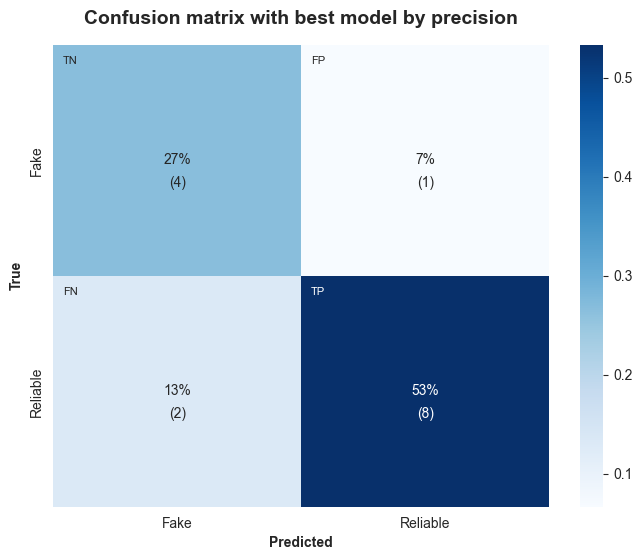

In [28]:
# Get label mapping
label_mapping = Dataset.LABELS_MAPPING

# Create and plot confusion matrix
cm = confusion_matrix(labels, predictions)
plt.figure(figsize=(8, 6))

# Calculate normalized confusion matrix by total counts
total = cm.sum()
cm_percentages = cm / total

# Create heatmap
hmap = sns.heatmap(cm_percentages, annot=True, fmt='.0%', cmap='Blues',
                   xticklabels=[label_mapping[0], label_mapping[1]],
                   yticklabels=[label_mapping[0], label_mapping[1]])

# Get the percentage labels (annotations)
texts = hmap.texts

# Add count annotations below percentages and confusion matrix labels
confusion_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(len(cm)):
    for j in range(len(cm)):
        # Get the color of the percentage text
        text_color = texts[i * len(cm) + j].get_color()

        # Add count annotation
        plt.text(j + 0.5, i + 0.6, f'({cm[i, j]})',
                 ha='center', va='center', color=text_color)

        # Add confusion matrix label (TN, FP, FN, TP)
        plt.text(j + 0.04, i + 0.07, confusion_labels[i][j],
                 ha='left', va='center', color=text_color,
                 fontsize=8)

plt.title(f'Confusion matrix with best model by {by_metric.name}',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('True', fontweight='bold')

# Save plot
plt.savefig(f'assets/confusion_matrix_by_{by_metric.name.lower()}.png',
            bbox_inches='tight',
            dpi=300)
plt.show()


### Metrics

In [29]:
metrics_labels_mapping = {'FPR': 'test_false_positive_rate', ''}
run.data.metrics

{'best_epoch': 3.0,
 'best_test_accuracy': 0.7475409836065574,
 'best_test_f1': 0.8221709006928406,
 'best_test_false_negative_rate': 0.11,
 'best_test_false_positive_rate': 0.5238095238095238,
 'best_test_loss': 0.5362418293952942,
 'best_test_precision': 0.7639484978540773,
 'best_test_recall': 0.89,
 'best_test_roc_auc': 0.7826666666666667,
 'best_test_runtime': 10.9588,
 'best_test_samples_per_second': 27.832,
 'best_test_steps_per_second': 3.559,
 'epoch': 3.0,
 'eval_accuracy': 0.8401408450704225,
 'eval_f1': 0.8854114083796063,
 'eval_false_negative_rate': 0.07391763463569166,
 'eval_false_positive_rate': 0.33192389006342493,
 'eval_loss': 0.38889172673225403,
 'eval_precision': 0.8481624758220503,
 'eval_recall': 0.9260823653643083,
 'eval_roc_auc': 0.8866946025169055,
 'eval_runtime': 46.384,
 'eval_samples_per_second': 30.614,
 'eval_steps_per_second': 3.838,
 'grad_norm': 18.716386795043945,
 'learning_rate': 3.7453183520599253e-07,
 'loss': 0.464,
 'test_accuracy': 0.747540